In [6]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\aditi\OneDrive\Desktop\business sales analysis 01\anaconda_projects\db\Cleaned_Superstore.csv"
)

print("Dataset loaded successfully!")
print(df.head())
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

Dataset loaded successfully!
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cat

In [7]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
average_order_value = df.groupby("Order ID")["Sales"].sum().mean()
total_orders = df["Order ID"].nunique()
quantity_sold = df["Quantity"].sum()
best_product = df.groupby("Product Name")["Sales"].sum().idxmax()

highest_profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .idxmax()
)
df["YearMonth"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("YearMonth")["Sales"].sum()
sales_growth = monthly_sales.pct_change().mean() * 100

print("===== KPI SUMMARY =====")
print("Total Sales: $", round(total_sales, 2))
print("Total Profit: $", round(total_profit, 2))
print("Profit Margin: {:.2f}%".format(profit_margin))
print("Average Order Value: $", round(average_order_value, 2))
print("Sales Growth Rate: {:.2f}%".format(sales_growth))
print("Total Orders:", total_orders)
print("Quantity Sold:", quantity_sold)
print("Best Selling Product:", best_product)
print("Highest Profit Category:", highest_profit_category)

===== KPI SUMMARY =====
Total Sales: $ 2297200.86
Total Profit: $ 286397.02
Profit Margin: 12.47%
Average Order Value: $ 458.61
Sales Growth Rate: 41.56%
Total Orders: 5009
Quantity Sold: 37873
Best Selling Product: Canon imageCLASS 2200 Advanced Copier
Highest Profit Category: Technology


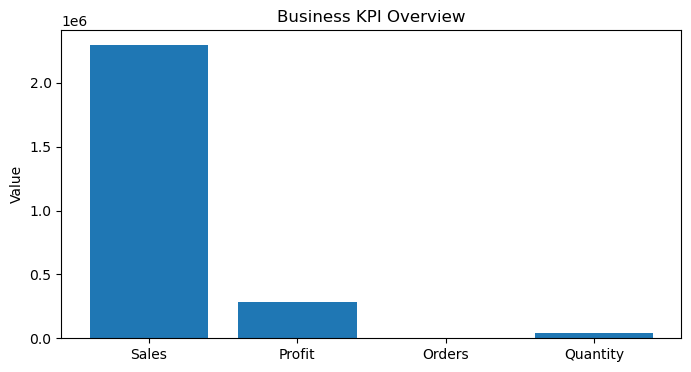

In [8]:
#kpi cards
import matplotlib.pyplot as plt

kpis = {
    "Sales": round(total_sales, 0),
    "Profit": round(total_profit, 0),
    "Orders": total_orders,
    "Quantity": quantity_sold
}

plt.figure(figsize=(8,4))

plt.bar(kpis.keys(), kpis.values())

plt.title("Business KPI Overview")
plt.ylabel("Value")

plt.show()